# Competencia de Aprendizaje de Máquina 2026-20
## Parte 1: Clasificación de sentimientos en reseñas de productos

### 1. Introducción

El presente proyecto tiene como objetivo desarrollar un modelo de aprendizaje de máquina capaz de clasificar reseñas de productos escritas en español según el sentimiento general expresado por el usuario. Para ello, se consideran tres posibles categorías: positivo, negativo y neutral.

La principal dificultad consiste en identificar correctamente el sentimiento global de una reseña, especialmente cuando contiene opiniones mixtas, negaciones o expresiones que pueden cambiar el sentido de una oración.

En esta primera etapa se utilizarán técnicas de aprendizaje de máquina clásico, siguiendo las restricciones establecidas para la competencia. Se explorarán diferentes estrategias de representación de texto, como Bag-of-Words, TF-IDF y n-gramas, junto con modelos de clasificación implementados en scikit-learn.

Seguiremos el mismo flujo de las prácticas: exploración de los datos, preparación del texto, entrenamiento, validación y comparación de modelos. Como en la competencia de Kaggle, la métrica principal será la accuracy.

### 2. Importación de librerías

Usaremos pandas para cargar y manipular los datos, NumPy para operaciones numéricas y Matplotlib para las gráficas de la exploración.

In [ ]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np

### 3. Carga de los datos

Para desarrollar el modelo se utilizarán los conjuntos de datos proporcionados por la competencia de Kaggle.

El archivo `train.csv` contiene las reseñas de productos y sus respectivas etiquetas de sentimiento. Este conjunto se utilizará para explorar los datos y posteriormente entrenar y validar los modelos.

Por otra parte, el archivo `eval.csv` contiene las reseñas que deberán ser clasificadas para realizar los envíos a Kaggle. A diferencia del conjunto de entrenamiento, este archivo no incluye las etiquetas correspondientes.

Cargamos ambos archivos y revisamos sus dimensiones para confirmar que se leyeron bien.

In [ ]:
from pathlib import Path

# Ubicación de los datos
data_dir = Path("data")

# Si el notebook se ejecuta desde la carpeta notebooks
if not data_dir.exists():
    data_dir = Path("../data")

# Cargar los archivos
train = pd.read_csv(data_dir / "train.csv")
eval_data = pd.read_csv(data_dir / "eval.csv")

# Verificar dimensiones
print("Entrenamiento:", train.shape)
print("Evaluación:", eval_data.shape)


Entrenamiento: (12000, 3)
Evaluación: (3000, 2)


### 4. Exploración inicial de los datos

Con `head()` vemos los primeros registros y el tipo de texto de las reseñas, y con `info()` revisamos la cantidad de registros, los tipos de datos y los valores no nulos de cada columna.

In [5]:
# Visualizar los primeros cinco registros
display(train.head())

# Consultar la estructura del conjunto de datos
train.info()


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      12000 non-null  int64
 1   text    12000 non-null  str  
 2   label   12000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 281.4 KB


### 5. Revisión de la calidad de los datos

Como en la práctica de exploración y calidad de datos, revisamos la completitud y la unicidad: valores faltantes, filas duplicadas, identificadores repetidos y textos repetidos. Un texto duplicado es especialmente importante, porque si queda una copia en entrenamiento y otra en validación, la evaluación sale inflada.

In [6]:
# valores faltantes
print("Valores faltantes por columna:")
print(train.isnull().sum())

#  filas completamente duplicadas
print("\nFilas duplicadas:")
print(train.duplicated().sum())

# IDs repetidos
print("\nIdentificadores duplicados:")
print(train["id"].duplicated().sum())

# textos repetidos
print("\nTextos duplicados:")
print(train["text"].duplicated().sum())


Valores faltantes por columna:
id       0
text     0
label    0
dtype: int64

Filas duplicadas:
0

Identificadores duplicados:
0

Textos duplicados:
0


### 5.1. Resultados de la revisión de calidad

El conjunto de entrenamiento contiene 12.000 registros y tres columnas: `id`, `text` y `label`. La primera corresponde al identificador de cada reseña, la segunda contiene el texto de la opinión y la tercera indica el sentimiento asociado.

Al revisar la calidad de los datos, se encontró que ninguna de las columnas presenta valores faltantes. Tampoco se identificaron filas duplicadas, identificadores repetidos ni textos exactamente iguales.

Por lo tanto, no hace falta eliminar registros ni tratar valores nulos.

### 6. Distribución de las clases

Revisamos cuántas reseñas hay de cada sentimiento. Si una clase tuviera muchos más ejemplos que las otras, algunos clasificadores tenderían a favorecerla y la accuracy podría ser engañosa, como se vio en las prácticas de KNN y Random Forest.

Cantidad de reseñas por sentimiento:
label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

Porcentaje por sentimiento:
label
positivo    35.1
negativo    35.1
neutral     29.8
Name: proportion, dtype: float64


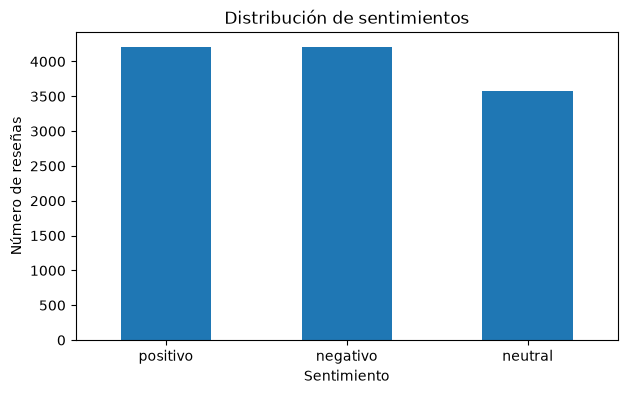

In [ ]:
# Cantidad de reseñas por sentimiento
conteo = train["label"].value_counts()

# Porcentaje por sentimiento
porcentajes = train["label"].value_counts(normalize=True) * 100

print("Cantidad de reseñas por sentimiento:")
print(conteo)

print("\nPorcentaje por sentimiento:")
print(porcentajes.round(2))

# Grafica
conteo.plot(kind="bar", figsize=(7, 4))

plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Número de reseñas")
plt.xticks(rotation=0)
plt.show()


### 6.1. Interpretación de la distribución de clases

El conjunto de entrenamiento contiene 4.212 reseñas positivas, 4.212 negativas y 3.576 neutrales, que representan el 35,1%, 35,1% y 29,8% de los registros, respectivamente.

Se observa que las clases positiva y negativa tienen exactamente la misma cantidad de ejemplos, mientras que la clase neutral presenta una proporción ligeramente menor. Sin embargo, la diferencia no es demasiado grande, por lo que el conjunto de datos se encuentra relativamente equilibrado.

Con esta distribución no vemos necesario aplicar técnicas de balanceo como SMOTE o `class_weight` por ahora. Al dividir los datos usaremos una partición estratificada para conservar estas proporciones en entrenamiento y validación.

### 7. Análisis de las características del texto

Analizamos la longitud de las reseñas en caracteres y en palabras, y la comparamos entre sentimientos para ver si la longitud por sí sola dice algo sobre la clase.

In [8]:
# Crear una copia para el análisis exploratorio
train_eda = train.copy()

# Calcular la longitud de cada reseña
train_eda["num_caracteres"] = train_eda["text"].str.len()
train_eda["num_palabras"] = train_eda["text"].str.split().str.len()

# Mostrar estadísticas descriptivas
train_eda[["num_caracteres", "num_palabras"]].describe()


,num_caracteres,num_palabras
count,12000.000000,12000.000000
mean,281.380500,53.920500
std,69.218982,13.217674
min,14.000000,3.000000
25%,245.000000,47.000000
50%,280.000000,54.000000
75%,320.000000,61.000000
max,579.000000,110.000000


### 7.1. Distribución de la longitud de las reseñas

El histograma muestra las longitudes más comunes y si hay reseñas mucho más largas que el resto. Después comparamos el número de palabras por sentimiento con diagramas de caja.

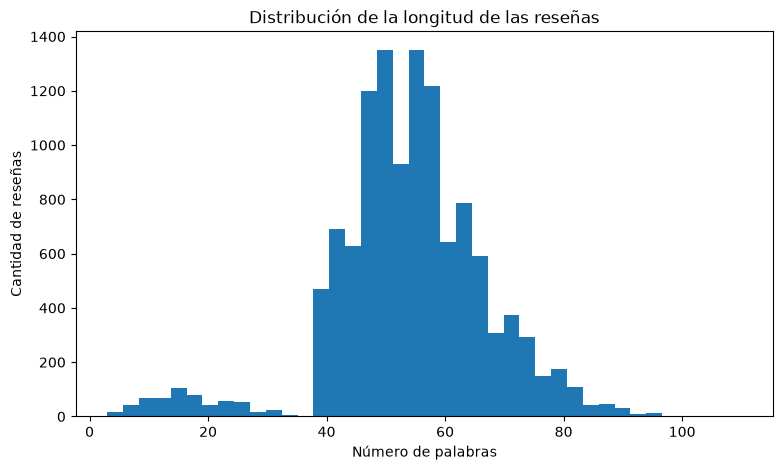

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.233381,12.733011,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.283557,13.851303,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,54.997388,13.010481,5.0,48.0,55.0,62.0,110.0


In [9]:
# Histograma de cantidad de palabras
plt.figure(figsize=(9, 5))

plt.hist(train_eda["num_palabras"], bins=40)

plt.title("Distribución de la longitud de las reseñas")
plt.xlabel("Número de palabras")
plt.ylabel("Cantidad de reseñas")
plt.show()

# Estadísticas por sentimiento
train_eda.groupby("label")["num_palabras"].describe()


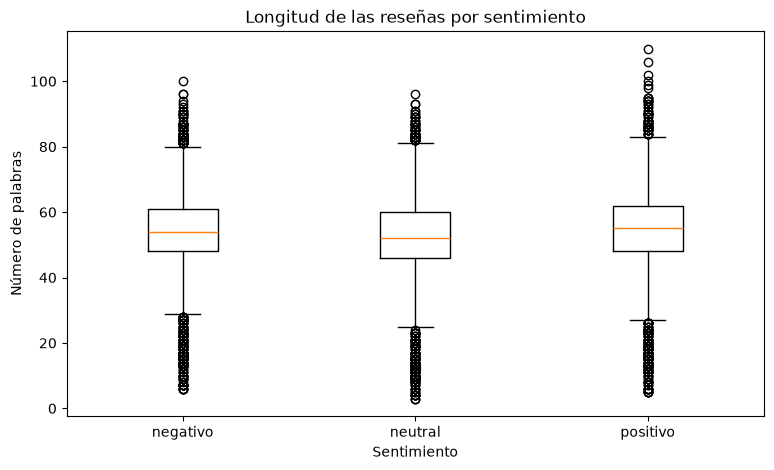

In [10]:

plt.figure(figsize=(9, 5))

orden = ["negativo", "neutral", "positivo"]

datos = [
    train_eda.loc[train_eda["label"] == sentimiento, "num_palabras"]
    for sentimiento in orden
]

plt.boxplot(datos, tick_labels=orden)

plt.title("Longitud de las reseñas por sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Número de palabras")
plt.show()


### 7.2. Interpretación de los resultados

El análisis de longitud muestra que las reseñas tienen un promedio de 53,92 palabras y 281,38 caracteres. La mediana es de 54 palabras, mientras que el 50% central de las reseñas contiene entre 47 y 61 palabras. Esto indica que la mayor parte de los textos tiene una longitud relativamente similar, aunque también existen reseñas considerablemente más cortas o extensas.

Al comparar las categorías de sentimiento, se observa que las reseñas positivas tienen un promedio de 55 palabras, las negativas de 54,23 y las neutrales de 52,28. Las medianas también son cercanas, con 55, 54 y 52 palabras, respectivamente.

En los diagramas de caja se observa una dispersión semejante entre las tres categorías, junto con valores atípicos de reseñas cortas y largas. Aunque las reseñas positivas tienden a ser ligeramente más extensas y las neutrales un poco más cortas, las distribuciones presentan un solapamiento considerable.

Por lo tanto, no se observa una diferencia suficientemente marcada como para considerar que la longitud de las reseñas permita distinguir claramente su sentimiento. Esto sugiere que será más importante analizar el contenido textual mediante técnicas como TF-IDF y n-gramas, que permitan representar las palabras y expresiones presentes en cada reseña.

Por el momento, no se eliminarán las reseñas consideradas atípicas únicamente por su longitud, ya que podrían contener información útil para el entrenamiento del modelo.

### 8. Partición de los datos

Dividimos los datos en 80% para entrenamiento y 20% para validación. Los modelos aprenden con el primer conjunto, y el segundo sirve para medir cómo clasifican reseñas que no vieron durante el ajuste.

Usamos `stratify=y` para mantener la proporción de las tres clases en ambos conjuntos y fijamos `random_state=42`, para que la partición sea la misma en todos los notebooks del equipo.

In [11]:
from sklearn.model_selection import train_test_split

# Variable de entrada: texto de la reseña
X = train["text"]

# Variable objetivo: sentimiento
y = train["label"]

# División estratificada
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", len(X_train))
print("Datos de validación:", len(X_val))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución en validación:")
print(y_val.value_counts(normalize=True).round(3))


Datos de entrenamiento: 9600
Datos de validación: 2400

Distribución en entrenamiento:
label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64

Distribución en validación:
label
negativo    0.351
positivo    0.351
neutral     0.298
Name: proportion, dtype: float64


### 8.1. Resultados de la partición

El conjunto de datos fue dividido en 9.600 registros para entrenamiento y 2.400 para validación, correspondientes al 80% y 20% del total, respectivamente.

Se utilizó una partición estratificada para conservar la distribución de las tres categorías de sentimiento. Los resultados muestran que ambos conjuntos mantienen aproximadamente un 35,1% de reseñas positivas, un 35,1% de reseñas negativas y un 29,8% de reseñas neutrales.

Al usar la misma semilla, todos los modelos del equipo se evalúan sobre las mismas reseñas y sus resultados se pueden comparar directamente.